# 4. Adapt the model architecture and training pipeline to your local context

## 4.1 Architectural Modifications

- **Expanded input dimensions**  
  The original 4-channel input (RGB + NIR) was extended to **6 channels** by adding SWIR bands B11 and B12. These bands are particularly sensitive to snow, ice and moisture, improving the model’s ability to separate ice from water, shadow, or debris-covered glacier surfaces.

- **Adaptation of the first convolutional layer**  
  The first convolution block was updated to accept a 6-channel tensor. All subsequent layers remained unchanged to preserve consistency with the baseline model.

- **Addition of dropout in the bottleneck**  
  A dropout layer was inserted in the bottleneck to reduce overfitting. Glacier imagery exhibits high spatial redundancy (large homogeneous ice surfaces), making dropout beneficial for improving generalisation.

- **Switch to Dice loss**  
  Dice loss replaced binary cross-entropy because glacier segmentation is highly imbalanced (ice occupies only a small portion of many tiles (12% of the pixels)). Dice loss directly optimises overlap between prediction and ground truth, making it more robust in settings where the positive class is underrepresented. It is a well known loss metric when working with imbalanced data for image segmentation.

- **Data augmentation**  
  Augmentation was adapted to glacier imagery using horizontal/vertical flips, rotations and slight brightness variations. These transformations reflect realistic perturbations in mountain viewing geometry and variable illumination, improving robustness. The original paper did not apply augmentation to the 4-band dataset, only for the 3-band dataset.

- **Learning-rate scheduling**  
  A ReduceLROnPlateau callback was used to halve the learning rate when validation Dice did not improve for 5 epochs. This stabilises convergence and prevents the model from overshooting local minima.

- **Model checkpointing and early stopping**  
  The best-performing model (based on validation Dice) was automatically saved. Early stopping with a patience of 10 epochs prevents unnecessary computation and mitigates overfitting if needed.

- **Batch size adjustment**  
  Batch size was increased from **1 to 4**, improving gradient stability and making more efficient use of GPU memory compared to the original setup.

- **Core architecture preserved**  
  Encoder depth, number of filters, skip connections, attention gates and decoder structure were kept identical to the original Attention U-Net to ensure comparability and maintain compatibility with partial fine-tuning.

- **Fine-tuning setup**  
  The model was fine-tuned using a full retraining approach, allowing all parameters to update during optimisation. This choice is motivated by the substantial domain shift between the original application, tropical forest cover segmentation, and the new task of alpine glacier delineation. Sentinel-2 imagery over high-mountain environments exhibits fundamentally different spectral behaviour: snow and glacier ice have distinct reflectance patterns in the visible, NIR, and especially SWIR bands; debris-covered glaciers introduce complex, low-contrast textures; and steep terrain produces characteristic shadowing effects absent in rainforest imagery. Firt, there was an attempt to unfreeze only the first convolutional layers (adapted for 6 channels) and the decoder, while encoder layers remained frozen. This resulted in bad performance and instable convergence in the learning curves, which is why we switched to full-model fine-tuning.

## 4.2 Fine-tuning process



The fine-tuning process involved systematic exploration of hyperparameter
configurations to optimise transfer learning from Amazon deforestation
detection to Swiss Alps glacier segmentation. Initial experiments with encoder
freezing (maintaining pre-trained Amazon weights without updates) produced poor
results with highly unstable learning curves. This instability likely arose
because the spectral signatures of vegetation and ice differ substantially
despite both being binary segmentation tasks, requiring significant weight
adjustments rather than mere fine-tuning of the decoder. Consequently, all
subsequent experiments allowed full gradient flow through the network, enabling
adaptation of all 2.01M parameters to the glacier detection domain. This
approach resulted in significantly improved performance and smoother training dynamics.

Six distinct configurations were systematically evaluated across 60 epochs each,
exploring the interaction effects of batch size, learning rate, and learning rate
reduction schedules. Due to computational constraints (limited GPU memory and training
time), the hyperparameter search focused on these critical parameters whilst maintaining
constant dropout (0.5) and early stopping patience (10 epochs). The six experiments
comprised: (1) conservative settings with batch_size=4 and lr=5e-5, (2) aggressive
learning with batch_size=2 and lr=1e-4, (3) binary cross-entropy loss comparison,
(4) moderate batch with increased learning rate (batch=4, lr=1e-4), (5) aggressive
scheduler with conservative learning rate (lr=5e-5, reduce_lr_factor=0.3), and
(6) combined aggressive approach (lr=1e-4, reduce_lr_factor=0.3).

Analysis of learning curves and validation performance revealed a counterintuitive
finding: configurations employing higher learning rates (lr=1e-4) consistently
outperformed conservative approaches (lr=5e-5), with Experiment 2 achieving the
highest test Dice coefficient (0.9694) compared to Experiment 1's substantially
lower performance (0.9446). The conservative configuration exhibited variable
training behaviour including oscillating training accuracy (0.85-1.0) and a
dramatic loss spike at epoch 55, triggered by ReduceLROnPlateau reducing
an already insufficient learning rate. In contrast, Experiment 2 demonstrated
smooth exponential decay in both training and validation metrics, converging
around epoch 20 and maintaining stability thereafter.

The superior performance of the aggressive configuration (batch=2, lr=1e-4,
reduce_lr_factor=0.3) can be attributed to transfer learning dynamics. Pre-trained
Amazon weights represent a local minimum optimised for vegetation detection;
adapting these features to ice spectral signatures requires sufficient learning
rate magnitude to escape this minimum and explore the glacier detection loss
landscape. The small batch size (401 gradient updates per epoch) further enhanced
exploration through gradient noise regularisation, whilst the moderate reduce_lr
_factor=0.3 enabled convergence without premature stagnation.

Comparative analysis across all experiments confirmed that learning rate constitutes
the critical hyperparameter: all three top-performing models employed lr=1e-4, whilst models using lr=5e-5 achieved markedly
inferior performance. Batch size demonstrated secondary importance,
with batch=2 slightly outperforming batch=4, suggesting both
configurations work effectively with appropriate learning rate selection.

The final selected configuration (Experiment 2: batch_size=2, lr=1e-4, dropout=0.5,
reduce_lr_factor=0.3) achieved validation Dice coefficient of 0.9759 and test Dice
of 0.9694, representing optimal performance amongst all evaluated hyperparameter
combinations. It also achieved the highest accuracy on the dataset.

## 4.3 Fine-tuning of model: implementation

### Imports

In [1]:
# Import packages
import keras
keras.config.set_backend("tensorflow")

from keras.models import Model
from keras.layers import *
from keras.saving import load_model
from keras.optimizers import *
from keras.losses import *
from keras import backend as K
from keras.callbacks import ModelCheckpoint, EarlyStopping

import tensorflow as tf
import numpy as np
import pandas as pd
import os

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.callbacks import ReduceLROnPlateau

import rasterio
import requests
# import pyunpack
import matplotlib.pyplot as plt
import PIL
from PIL import Image
import glob

from sklearn.metrics import *

In [3]:
# go to the repo root
os.chdir('/content/Deforestation_Detection')

# just to check:
print(os.getcwd())
print(os.listdir())

/content/Deforestation_Detection
['predictor.py', '.ipynb_checkpoints', '2_Local_Challenge.ipynb', '.gitignore', '5_Evaluation.ipynb', 'data', '4_Model_Application.ipynb', 'attention_unet', '1_Replication.ipynb', '3_Dataset_Curation.ipynb', 'models_paper', 'test', 'images', 'train', 'preprocessing_paper', 'environment.yml', 'metrics_paper', 'val', 'models_switzerland', '.gitmodules', 'preprocessing_switzerland', 'README.md', '.git']


### Read in data and model

In [ ]:
original_model = load_model('models_paper/unet-attention-4d.keras')

In [ ]:
original_model.summary()

Model: "functional_14"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_25      │ (1, 512, 512, 4)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_531 (Conv2D) │ (1, 512, 512, 16) │        592 │ input_layer_25[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_478      │ (1, 512, 512, 16) │          0 │ conv2d_531[0][0]  │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_532 (Conv2D) │ (1, 512, 512, 16) │      2,320 │ activation_478[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_479      │ (1, 512, 512, 16) │          0 │ conv2d_532[0][0]  │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_153   │ (1, 256, 256, 16) │          0 │ activation_479[0… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_533 (Conv2D) │ (1, 256, 256, 32) │      4,640 │ max_pooling2d_15… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_480      │ (1, 256, 256, 32) │          0 │ conv2d_533[0][0]  │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_534 (Conv2D) │ (1, 256, 256, 32) │      9,248 │ activation_480[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_481      │ (1, 256, 256, 32) │          0 │ conv2d_534[0][0]  │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_154   │ (1, 128, 128, 32) │          0 │ activation_481[0… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_535 (Conv2D) │ (1, 128, 128, 64) │     18,496 │ max_pooling2d_15… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_482      │ (1, 128, 128, 64) │          0 │ conv2d_535[0][0]  │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_536 (Conv2D) │ (1, 128, 128, 64) │     36,928 │ activation_482[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_483      │ (1, 128, 128, 64) │          0 │ conv2d_536[0][0]  │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_155   │ (1, 64, 64, 64)   │          0 │ activation_483[0… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_537 (Conv2D) │ (1, 64, 64, 128)  │     73,856 │ max_pooling2d_15… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_484      │ (1, 64, 64, 128)  │          0 │ conv2d_537[0][0]  │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_538 (Conv2D) │ (1, 64, 64, 128)  │    147,584 │ activation_484[0… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 6,019,310 (22.96 MB)

 Trainable params: 2,006,436 (7.65 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 4,012,874 (15.31 MB)

In [7]:
def load_npy_list(directory):
    files = sorted(glob.glob(os.path.join(directory, "*.npy")))
    arrays = [np.load(f) for f in files]
    return arrays, files

In [9]:
BASE_DIR = r"data_switzerland/preprocessed_data"
#BASE_DIR = "/content/Deforestation_Detection"

train_img_dir2 = os.path.join(BASE_DIR, "train", "X")
train_msk_dir2 = os.path.join(BASE_DIR, "train", "Y")
val_img_dir2   = os.path.join(BASE_DIR, "val", "X")
val_msk_dir2   = os.path.join(BASE_DIR, "val", "Y")
test_img_dir2 = os.path.join(BASE_DIR, "test", "X")
test_msk_dir2 = os.path.join(BASE_DIR, "test", "Y")

training_images2, training_image_files2   = load_npy_list(train_img_dir2)
training_masks2,  training_mask_files2    = load_npy_list(train_msk_dir2)
validation_images2, validation_img_files2 = load_npy_list(val_img_dir2)
validation_masks2,  validation_msk_files2 = load_npy_list(val_msk_dir2)
test_images2, test_image_files2   = load_npy_list(test_img_dir2)
test_masks2,  test_mask_files2    = load_npy_list(test_msk_dir2)


print(len(training_images2), len(validation_images2))
print("Example shape:", training_images2[0].shape)

801 100
Example shape: (512, 512, 6)


In [7]:
# Create TensorFlow datasets for training and validation sets
train_df_switz = tf.data.Dataset.from_tensor_slices((training_images2, training_masks2))
val_df_swit = tf.data.Dataset.from_tensor_slices((validation_images2, validation_masks2))

In [ ]:
def assess_class_imbalance(masks):
    """
    Calculate and report ice/non-ice pixel distribution
    """
    # Convert list to numpy array if needed
    if isinstance(masks, list):
        masks = np.array(masks)

    # Ensure correct shape (N, H, W) or (N, H, W, 1)
    if masks.ndim == 3:
        masks = masks[..., np.newaxis]  # Add channel dimension

    ice_pixels = masks.sum()
    total_pixels = masks.size
    ice_ratio = ice_pixels / total_pixels

    print("="*60)
    print("CLASS IMBALANCE ANALYSIS")
    print("="*60)
    print(f"Data type:           {type(masks)}")
    print(f"Shape:               {masks.shape}")
    print(f"Total pixels:        {total_pixels:,}")
    print(f"Ice pixels:          {int(ice_pixels):,} ({ice_ratio:.2%})")
    print(f"Non-ice pixels:      {int(total_pixels - ice_pixels):,} ({1-ice_ratio:.2%})")

    if ice_ratio > 0:
        imbalance_ratio = (1 - ice_ratio) / ice_ratio
        print(f"Imbalance ratio:     {imbalance_ratio:.2f}:1 (non-ice:ice)")
    else:
        print(f"WARNING: No ice pixels found!")

    print("="*60)

    return {
        'ice_ratio': ice_ratio,
        'non_ice_ratio': 1 - ice_ratio,
        'imbalance_ratio': (1-ice_ratio) / ice_ratio if ice_ratio > 0 else float('inf')
    }

assess_class_imbalance(training_masks2)

CLASS IMBALANCE ANALYSIS
Data type:           <class 'numpy.ndarray'>
Shape:               (801, 512, 512, 1)
Total pixels:        209,977,344
Ice pixels:          28,711,938 (13.67%)
Non-ice pixels:      181,265,406 (86.33%)
Imbalance ratio:     6.31:1 (non-ice:ice)


{'ice_ratio': np.float64(0.1367382663912541),
 'non_ice_ratio': np.float64(0.8632617336087459),
 'imbalance_ratio': np.float64(6.313241760274071)}

### Model

In [8]:
# --- HELPER FUNCTIONS FOR UNETAM ARCHITECTURE ---

def convBlock(input_tensor, filters, kernel, kernel_init='he_normal', act='relu', transpose=False):
    """
    Convolutional block with set parameters and activation layer.
    Can perform Conv2D (encoder) or Conv2DTranspose (decoder upsampling).
    """
    if transpose is False:
        conv = Conv2D(filters, kernel, padding='same', kernel_initializer=kernel_init)(input_tensor)
    else:
        # Used for the final output block (UNetAM_Transfer line 133)
        conv = Conv2DTranspose(filters, kernel, padding='same', kernel_initializer=kernel_init)(input_tensor)

    conv = Activation(act)(conv)
    return conv


def convBlock2(input_tensor, filters, kernel, kernel_init='he_normal', act='relu', transpose=False):
    """
    Convolutional block with two Conv/ConvTranspose layers and two activation layers.
    Used throughout the Encoder and Decoder blocks.
    """
    if transpose is False:
        conv = Conv2D(filters, kernel, padding='same', kernel_initializer=kernel_init)(input_tensor)
        conv = Activation(act)(conv)
        conv = Conv2D(filters, kernel, padding='same', kernel_initializer=kernel_init)(conv)
        conv = Activation(act)(conv)
    else:
        conv = Conv2DTranspose(filters, kernel, padding='same', kernel_initializer=kernel_init)(input_tensor)
        conv = Activation(act)(conv)
        conv = Conv2DTranspose(filters, kernel, padding='same', kernel_initializer=kernel_init)(conv)
        conv = Activation(act)(conv)

    return conv

def attention_block(x, gating, inter_shape, drop_rate=0.25):
    """
    Attention mechanism block based on the UNetAM paper.
    x is the skip connection from the encoder (high resolution).
    gating is the input from the lower level (low resolution).
    """
    shape_x = x.shape

    # 1. Process x (skip connection)
    theta_x = Conv2D(inter_shape, kernel_size=1, strides=1, padding='same', kernel_initializer='he_normal', activation=None)(x)
    # Downsample x to match gating signal size
    theta_x = MaxPooling2D((2,2))(theta_x)

    # 2. Process gating signal
    phi_g = Conv2D(inter_shape, kernel_size=1, strides=1, padding='same', kernel_initializer='he_normal', activation=None)(gating)

    # 3. Combine and activate
    concat_xg = add([phi_g, theta_x])
    act_xg = Activation('relu')(concat_xg)

    # 4. Generate attention map (psi)
    psi = Conv2D(1, kernel_size=1, strides=1, padding='same', kernel_initializer='he_normal', activation=None)(act_xg)
    sigmoid_xg = Activation('sigmoid')(psi)
    shape_sigmoid = sigmoid_xg.shape

    # 5. Upsample attention map to match skip connection size
    upsample_factor = (
        shape_x[1] // shape_sigmoid[1],
        shape_x[2] // shape_sigmoid[2]
    )

    upsample_psi = UpSampling2D(
        size=upsample_factor,
        interpolation='bilinear'
    )(sigmoid_xg)

    # 6. Apply attention map to the skip connection (x * upsampled_attention_map)
    y = multiply([upsample_psi, x])

    return y

# --- 2. FINETUNING MODEL DEFINITION (6-BAND) ---
def UNetAM_Transfer(trained_weights_path,
                    input_size,
                    drop_rate,
                    lr,
                    filter_base,
                    loss_fn,
                    metrics_list):
    """
    Attention U-Net model adapted for 6-band input and configured for finetuning.

    Returns:
        keras.Model: Compiled 6-band Attention U-Net model.
    """

    # =========================================================================
    # INPUT LAYER
    # =========================================================================

    inputs = Input(input_size)

    # =========================================================================
    # ENCODER (Contraction Phase)
    # =========================================================================


    # Block 1 (512x512) - NEW LAYER for 6 channels, always trainable
    conv = convBlock2(inputs, filter_base, 3)
    conv0 = MaxPooling2D(pool_size=(2, 2), name='pool1')(conv) # Output: 256x256

    # Block 2 (256x256) - Pre-trained
    conv0 = convBlock2(conv0, 2 * filter_base, 3)
    pool0 = MaxPooling2D(pool_size=(2, 2), name='pool2')(conv0)  # Output: 128x128

    # Block 3 (128x128) - Pre-trained
    conv1 = convBlock2(pool0, 4 * filter_base, 3)
    pool1 = MaxPooling2D(pool_size=(2, 2), name='pool3')(conv1)  # Output: 64x64

    # Block 4 (64x64) - Pre-trained
    conv2 = convBlock2(pool1, 8 * filter_base, 3)
    pool2 = MaxPooling2D(pool_size=(2, 2), name='pool4')(conv2) # Output: 32x32

    # Block 5/Bottleneck (32x32) - Pre-trained
    conv3 = convBlock2(pool2, 16 * filter_base, 3)
    conv3 = Dropout(drop_rate, name='bottleneck_dropout')(conv3) # <-------- ADDED

    # =========================================================================
    # DECODER (Expansion Phase)
    # =========================================================================

    # Up-Conv 1 (32x32 -> 64x64)
    up4 = Conv2DTranspose(8 * filter_base, kernel_size=2, strides=2,
                          kernel_initializer='he_normal', name='upconv1')(conv3)
    merge4 = attention_block(conv2, conv3, 8 * filter_base, drop_rate)
    conv4 = concatenate([up4, merge4], name='concat1')
    conv4 = convBlock2(conv4, 8 * filter_base, 3)

    # Up-Conv 2 (64x64 -> 128x128)
    up5 = Conv2DTranspose(4 * filter_base, kernel_size=2, strides=2,
                          kernel_initializer='he_normal', name='upconv2')(conv4)
    merge5 = attention_block(conv1, conv4, 4 * filter_base, drop_rate)
    conv5 = concatenate([up5, merge5], name='concat2')
    conv5 = convBlock2(conv5, 4 * filter_base, 3)

    # Up-Conv 3 (128x128 -> 256x256)
    up6 = Conv2DTranspose(2 * filter_base, kernel_size=2, strides=2,
                          kernel_initializer='he_normal', name='upconv3')(conv5)
    merge6 = attention_block(conv0, conv5, 2 * filter_base, drop_rate)
    conv6 = concatenate([up6, merge6], name='concat3')
    conv6 = convBlock2(conv6, 2 * filter_base, 3)

    # Up-Conv 4 (256x256 -> 512x512)
    up7 = Conv2DTranspose(1 * filter_base, kernel_size=2, strides=2,
                          kernel_initializer='he_normal', name='upconv4')(conv6)
    merge7 = attention_block(conv, conv6, 1 * filter_base, drop_rate)
    conv7 = concatenate([up7, merge7], name='concat4')
    conv7 = convBlock2(conv7, 1 * filter_base, 3)

    # =========================================================================
    # OUTPUT LAYER: 512x512x1
    # =========================================================================

    out = convBlock(conv7, 1, 1, act='sigmoid')


    # =========================================================================
    # CREATE AND COMPILE MODEL
    # =========================================================================

    model = Model(inputs, out, name='UNet_Attention_FineTune')


    # 3. Load weights from the pre-trained 4-band model
    # if trained_weights_path:
    #     print(f"Loading weights from pre-trained model: {trained_weights_path}")
    #     try:
    #         # Load weights. 'by_name=True' matches layers by name.
    #         # 'skip_mismatch=True' ignores layers where shapes don't match (i.e., the first Conv2D layer).
    #         model.load_weights(trained_weights_path, skip_mismatch=True)
    #         print("Successfully loaded weights from the 4-band model into corresponding 6-band layers.")
    #     except Exception as e:
    #         print(f"ERROR: Could not load weights. Check file path or type. Details: {e}")


    if trained_weights_path:
        print("\n" + "="*70)
        print("LOADING PRE-TRAINED WEIGHTS")
        print("="*70)
        print(f"Source: {trained_weights_path}")

        try:
            # Load the entire pretrained model first
            pretrained_model = load_model(trained_weights_path)
            print(f"Pre-trained model loaded successfully")
            print(f"  Pre-trained layers: {len(pretrained_model.layers)}")
            print(f"  New model layers: {len(model.layers)}")

            # Get initial random weights for comparison
            first_conv_weights_before = model.layers[1].get_weights()[0].copy()

            # Strategy: Transfer weights layer-by-layer, skip first block
            transferred = 0
            skipped = 0
            skip_first_n = 6  # Skip input + first conv block + pool1

            print(f"\nTransferring weights (skipping first {skip_first_n} layers)...")

            for i in range(skip_first_n, min(len(model.layers), len(pretrained_model.layers))):
                new_layer = model.layers[i]
                old_layer = pretrained_model.layers[i]

                old_weights = old_layer.get_weights()

                if old_weights:  # Only transfer if layer has weights
                    try:
                        new_layer.set_weights(old_weights)
                        transferred += 1
                    except:
                        skipped += 1

            # Verify transfer worked by checking a known layer
            # Check layer 6 (first layer after skip)
            if len(model.layers) > 6:
                layer_6_weights_after = model.layers[6].get_weights()
                if layer_6_weights_after:
                    print(f"\n V Weight transfer verification:")
                    print(f"  Sample weight value: {layer_6_weights_after[0].flat[0]:.6f}")

            print(f"\nV Transfer complete:")
            print(f"  Transferred: {transferred} layers")
            print(f"  Skipped: {skipped} layers")
            print(f"  First {skip_first_n} layers: Random init (6-channel input)")

            # Calculate percentage
            total_params = model.count_params()
            first_block_params = sum([
                sum([np.prod(w.shape) for w in model.layers[i].get_weights()])
                for i in range(1, skip_first_n)
                if model.layers[i].get_weights()
            ])
            transferred_params = total_params - first_block_params

            print(f"\n  Weight statistics:")
            print(f"    Total params: {total_params:,}")
            print(f"    First block (random): {first_block_params:,} ({100*first_block_params/total_params:.1f}%)")
            print(f"    Transferred (Amazon): {transferred_params:,} ({100*transferred_params/total_params:.1f}%)")

        except FileNotFoundError:
            print(f"X ERROR: File not found: {trained_weights_path}")
            print(f"  Training will start from random initialization")
        except Exception as e:
            print(f"X ERROR: Could not load weights: {str(e)}")
            print(f"  Training will start from random initialization")
    else:
        print("\n⚠ No pre-trained weights provided")
        print("  Training will start from random initialization")



    # 4. Configure layer freezing for fine-tuning

    for layer in model.layers:
       layer.trainable = True

    total_params = model.count_params()
    trainable_params = sum([np.prod(w.shape) for w in model.trainable_weights])
    frozen_params = total_params - trainable_params

    print(f"\nTotal parameters: {total_params:,}")
    print(f"Trainable parameters: {trainable_params:,} ({100*trainable_params/total_params:.1f}%)")
    print(f"Frozen parameters: {frozen_params:,} ({100*frozen_params/total_params:.1f}%)")


    # 5. Compile the model
    model.compile(optimizer=Adam(learning_rate=lr),
                  loss=loss_fn,
                  metrics=metrics_list)

    return model

In [ ]:
# UNetAM_Transfer.summary()

### Improvements

#### A. Other Loss Function

- Switched to dice loss because it is better for segmentation as it directly measures overlap between prediction and ground truth, making it more robust than cross-entropy when classes are imbalanced (e.g., small glaciers vs. large background).

In [17]:
# --- DICE LOSS IMPLEMENTATION (Improved Loss Function) ---

def dice_coeff(y_true, y_pred, smooth=1e-6):
    """
    Dice coefficient for segmentation metric.
    """
    # 1. Flatten tensors to 1D vectors
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])

    # 2. Calculate intersection using tf.reduce_sum
    intersection = tf.reduce_sum(y_true_f * y_pred_f)

    # 3. Calculate denominator using tf.reduce_sum
    sum_true = tf.reduce_sum(y_true_f)
    sum_pred = tf.reduce_sum(y_pred_f)

    # 4. Return the Dice Coefficient formula
    return (2. * intersection + smooth) / (sum_true + sum_pred + smooth)

def dice_loss(y_true, y_pred):
    """Dice Loss function, which is 1 - Dice Coefficient."""
    return 1 - dice_coeff(y_true, y_pred)

#### B. Data augmentation

Data augmentation to improve generalisation:
- Random horizontal + vertical flips
- Random 90° rotations
- Random brightness shifts

In [11]:
def preprocess_and_augment(image, mask):

    # 0. Shape correction (if needed)
    image = tf.squeeze(image)  # Remove extra dimensions
    mask = tf.squeeze(mask)

    # 1. Ensure correct shapes
    mask = tf.expand_dims(mask, axis=-1)  # Add channel dimension to mask
    image = tf.ensure_shape(image, (TILE_SIZE, TILE_SIZE, INPUT_CHANNELS))

    # 2. Type casting
    image = tf.cast(image, tf.float32)
    mask = tf.cast(mask, tf.float32)

    # 3. Mask cleanup (ensure binary 0/1, just in case)
    mask = tf.where(mask > 0.5, 1.0, 0.0)


    # Random horizontal flip
    if tf.random.uniform(shape=[]) > 0.5:
        image = tf.image.flip_left_right(image)
        mask = tf.image.flip_left_right(mask)

    # Random vertical flip
    if tf.random.uniform(shape=[]) > 0.5:
        image = tf.image.flip_up_down(image)
        mask = tf.image.flip_up_down(mask)

    # Random rotation (0°, 90°, 180°, 270°)
    k = tf.random.uniform(shape=[], minval=0, maxval=4, dtype=tf.int32)
    image = tf.image.rot90(image, k)
    mask = tf.image.rot90(mask, k)

    # Random brightness (±20%) - satellite imagery variation
    if tf.random.uniform(shape=[]) > 0.5:
        brightness_delta = tf.random.uniform(shape=[], minval=-0.2, maxval=0.2)
        image = tf.clip_by_value(image + brightness_delta, 0.0, 1.0)

    # 4. Final shape guarantee
    image = tf.ensure_shape(image, (TILE_SIZE, TILE_SIZE, INPUT_CHANNELS))
    mask = tf.ensure_shape(mask, (TILE_SIZE, TILE_SIZE, 1))

    return image, mask


def preprocess_only(image, mask):
    """
    For validation: no augmentation, just shape/type handling
    """
    # Shape correction
    image = tf.squeeze(image)
    mask = tf.squeeze(mask)

    # Ensure shapes
    mask = tf.expand_dims(mask, axis=-1)
    image = tf.ensure_shape(image, (TILE_SIZE, TILE_SIZE, INPUT_CHANNELS))

    # Type casting
    image = tf.cast(image, tf.float32)
    mask = tf.cast(mask, tf.float32)

    # Mask cleanup
    mask = tf.where(mask > 0.5, 1.0, 0.0)

    # Final shapes
    image = tf.ensure_shape(image, (TILE_SIZE, TILE_SIZE, INPUT_CHANNELS))
    mask = tf.ensure_shape(mask, (TILE_SIZE, TILE_SIZE, 1))

    return image, mask

#### C. Learning Rate Schedule

- Add learning rate scheduler that reduces learning rate if it does not improve for a certain amountn of epochs (depending on patience settings).

#### D. Activate Drop-out & Early Stopping
- Activated drop-out between the different layers to increase robusteness
- See adjustments in `UNetAM_Transfer` model above
- EarlyStopping: Stop training if the metric doesn't improve after a 'patience' period (epochs)


### Fine-tune model

In [13]:
# --- FINETUNING CONFIGURATION ---

# Paths
MODEL_PATH_4BAND = 'models_paper/unet-attention-4d.keras'
NEW_MODEL_SAVE_PATH = 'models_switzerland/glacier_attention_unet_6band.keras'

# Hyperparameters
FINETUNE_LR = 0.00005
BATCH_SIZE = 4
EPOCHS = 60
FILTER_BASE = 16
TILE_SIZE = 512
INPUT_CHANNELS = 6

In [ ]:
# --- MODEL INITIALIZATION ---

new_model = UNetAM_Transfer(
    trained_weights_path=MODEL_PATH_4BAND,
    input_size=(TILE_SIZE, TILE_SIZE, INPUT_CHANNELS),
    filter_base=FILTER_BASE,
    lr=FINETUNE_LR,
    loss_fn=dice_loss,
    metrics_list=['accuracy', dice_coeff]
)

new_model.summary(expand_nested=True)

In [ ]:
# Apply the transformations to the datasets ----------

# Training Dataset Pipeline
train_dataset = train_df_switz.shuffle(buffer_size=100) \
                              .map(preprocess_and_augment, num_parallel_calls=tf.data.AUTOTUNE) \
                              .batch(BATCH_SIZE) \
                              .prefetch(tf.data.AUTOTUNE)


val_dataset = val_df_swit.map(preprocess_only, num_parallel_calls=tf.data.AUTOTUNE) \
                         .batch(BATCH_SIZE) \
                         .prefetch(tf.data.AUTOTUNE)

# Calculate Steps
NUM_TRAIN_SAMPLES = len(training_images2)
NUM_VAL_SAMPLES = len(validation_images2)

STEPS_PER_EPOCH = NUM_TRAIN_SAMPLES // BATCH_SIZE
VALIDATION_STEPS = NUM_VAL_SAMPLES // BATCH_SIZE

print(f"  Training samples:     {NUM_TRAIN_SAMPLES}")
print(f"  Validation samples:   {NUM_VAL_SAMPLES}")
print(f"  Batch size:           {BATCH_SIZE}")
print(f"  Steps per epoch:      {STEPS_PER_EPOCH}")
print(f"  Validation steps:     {VALIDATION_STEPS}")




✓ Pipeline configured:
  Training samples:     801
  Validation samples:   100
  Batch size:           4
  Steps per epoch:      200
  Validation steps:     25
  Augmentation:         ENABLED (training only)


In [ ]:
print("\n=== Verification: Layer Trainability ===")
for i, layer in enumerate(new_model.layers[:30]):  # Show first 30 layers
    status = "✓ TRAIN" if layer.trainable else "✗ FREEZE"
    print(f"{i:3d}. {status} | {layer.name:30s} | Params: {layer.count_params():>8,}")



=== Verification: Layer Trainability ===
  0. ✓ TRAIN | input_layer_1                  | Params:        0
  1. ✓ TRAIN | conv2d_31                      | Params:      880
  2. ✓ TRAIN | activation_27                  | Params:        0
  3. ✓ TRAIN | conv2d_32                      | Params:    2,320
  4. ✓ TRAIN | activation_28                  | Params:        0
  5. ✓ TRAIN | pool1                          | Params:        0
  6. ✓ TRAIN | conv2d_33                      | Params:    4,640
  7. ✓ TRAIN | activation_29                  | Params:        0
  8. ✓ TRAIN | conv2d_34                      | Params:    9,248
  9. ✓ TRAIN | activation_30                  | Params:        0
 10. ✓ TRAIN | pool2                          | Params:        0
 11. ✓ TRAIN | conv2d_35                      | Params:   18,496
 12. ✓ TRAIN | activation_31                  | Params:        0
 13. ✓ TRAIN | conv2d_36                      | Params:   36,928
 14. ✓ TRAIN | activation_32                  | 

In [12]:
# --- CALLBACKS ---

# ModelCheckpoint: Save the best model based on the validation Dice Coefficient
model_checkpoint = ModelCheckpoint(
    NEW_MODEL_SAVE_PATH,
    monitor='val_dice_coeff',
    mode='max', # Maximize the Dice Coefficient
    verbose=1,
    save_best_only=True
)

# EarlyStopping: Stop training if the metric doesn't improve after a 'patience' period (10 epochs)
early_stopping = EarlyStopping(
    monitor='val_dice_coeff',
    patience=10,
    mode='max',
    verbose=1,
    restore_best_weights=True # Restores the weights from the best epoch found
)

# Learning rate
reduce_lr = ReduceLROnPlateau(
    monitor='val_dice_coeff',
    factor=0.5,
    patience=5,
    min_lr=1e-7,
    mode='max',
    verbose=1
)

callbacks_list = [model_checkpoint, early_stopping, reduce_lr]

In [ ]:
# --- TRAINING ---

print(f"Training for {EPOCHS} epochs with Learning Rate: {FINETUNE_LR} and Loss: Dice Loss.")

new_model.fit(
    train_dataset,
    steps_per_epoch=STEPS_PER_EPOCH,
    epochs=EPOCHS,
    callbacks=callbacks_list,
    validation_data=val_dataset,
    validation_steps=VALIDATION_STEPS
)

Training for 60 epochs with Learning Rate: 5e-05 and Loss: Dice Loss.
Epoch 1/60
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step - accuracy: 0.4910 - dice_coeff: 0.1743 - loss: 0.8257
Epoch 1: val_dice_coeff improved from -inf to 0.35454, saving model to models_switzerland/glacier_attention_unet_6band.keras
200/200 ━━━━━━━━━━━━━━━━━━━━ 78s 186ms/step - accuracy: 0.4914 - dice_coeff: 0.1747 - loss: 0.8253 - val_accuracy: 0.8841 - val_dice_coeff: 0.3545 - val_loss: 0.6455 - learning_rate: 5.0000e-05
Epoch 2/60
  1/200 ━━━━━━━━━━━━━━━━━━━━ 1:03:05 19s/step - accuracy: 0.7087 - dice_coeff: 0.6950 - loss: 0.3050

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 2: val_dice_coeff improved from 0.35454 to 0.35660, saving model to models_switzerland/glacier_attention_unet_6band.keras
200/200 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - accuracy: 0.7087 - dice_coeff: 0.6950 - loss: 0.3050 - val_accuracy: 0.8876 - val_dice_coeff: 0.3566 - val_loss: 0.6434 - learning_rate: 5.0000e-05
Epoch 3/60
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - accuracy: 0.9156 - dice_coeff: 0.3838 - loss: 0.6162
Epoch 3: val_dice_coeff improved from 0.35660 to 0.72824, saving model to models_switzerland/glacier_attention_unet_6band.keras
200/200 ━━━━━━━━━━━━━━━━━━━━ 32s 158ms/step - accuracy: 0.9156 - dice_coeff: 0.3846 - loss: 0.6154 - val_accuracy: 0.9375 - val_dice_coeff: 0.7282 - val_loss: 0.2718 - learning_rate: 5.0000e-05
Epoch 4/60
  1/200 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - accuracy: 0.9720 - dice_coeff: 0.7004 - loss: 0.2996
Epoch 4: val_dice_coeff did not improve from 0.72824
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9720 - dice_coeff: 0.7004 - loss

In [ ]:
# Save model history
np.save('models_switzerland/glacier_attention_unet_6band_history.npy', new_model.history.history)

## 4.3 Performance & Learning Curves

### Baseline model

In [ ]:
PARAMETERS = {
    'batch_size': 4,
    'lr': 0.00005,
    'drop_rate': 0.5,
    'patience': 10,
    'epochs': 60,
    'reduce_lr_factor': 0.5
}

In [ ]:
# Load models and history stats
attention_unet = load_model(
    'models_switzerland/glacier_attention_unet_6band.keras',
    # Pass both custom functions in the dictionary
    custom_objects={
        'dice_loss': dice_loss,  # The loss function used for compilation
        'dice_coeff': dice_coeff # The helper function called by the loss function
    }
)
history = np.load('models_switzerland/glacier_attention_unet_6band_history.npy', allow_pickle='TRUE').item()

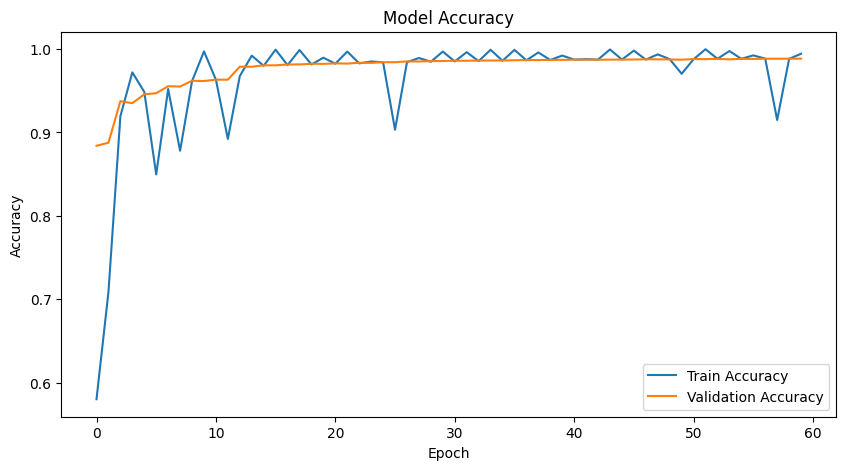

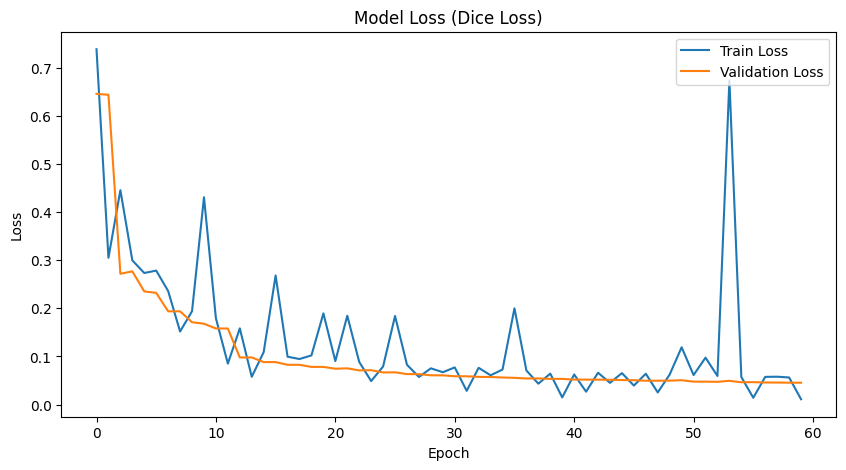

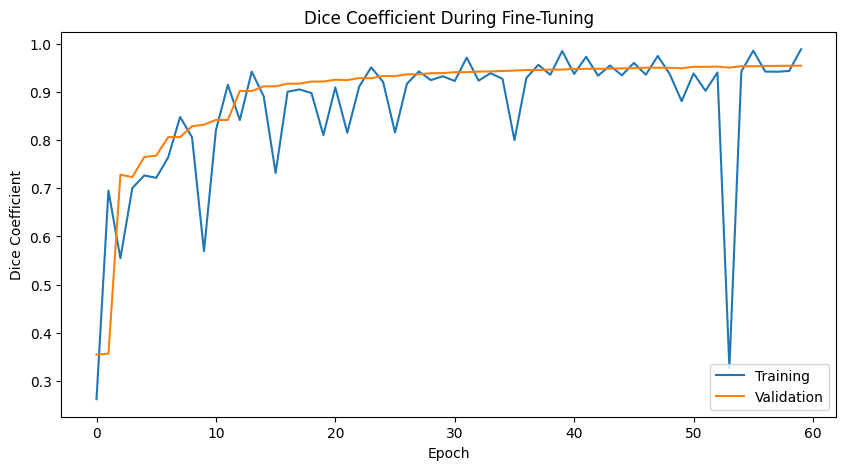

In [ ]:
import matplotlib.pyplot as plt

# Plot accuracy and loss for Attention U-Net
history = np.load('models_switzerland/glacier_attention_unet_6band_history.npy', allow_pickle='TRUE').item()

## Accuracy
plt.figure(figsize=(10, 5))
plt.plot(history['accuracy'], label='Train Accuracy')
plt.plot(history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='lower right')
plt.show()

## Loss
plt.figure(figsize=(10, 5))
plt.plot(history['loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Model Loss (Dice Loss)')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.show()

# Dice Coeff
plt.figure(figsize=(10, 5))
plt.plot(history['dice_coeff'])
plt.plot(history['val_dice_coeff'])
plt.ylabel('Dice Coefficient')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='lower right')
plt.title('Dice Coefficient During Fine-Tuning')
plt.show()

## Hyperparameter Tuning: Abliation Study

#### TEST 2: Other Parameters (aggresive)

In [ ]:
EXPERIMENT = {
    'batch_size': 2,      # ← CHANGED
    'lr': 0.0001,           # ← CHANGED
    'drop_rate': 0.5,
    'patience': 10,
    'epochs': 60,
    'reduce_lr_factor': 0.3  # ← NEW: More aggressive LR reduction
}

In [ ]:
# 1. Create model with experiment settings
test_model = UNetAM_Transfer(
    trained_weights_path=MODEL_PATH_4BAND,
    input_size=(512, 512, 6),
    drop_rate=EXPERIMENT['drop_rate'],
    lr=EXPERIMENT['lr'],
    loss_fn=dice_loss,
    metrics_list=[dice_coeff, 'accuracy']
)


# Training Dataset Pipeline (WITH augmentation)
train_dataset = train_df_switz.shuffle(buffer_size=100) \
                              .map(preprocess_and_augment, num_parallel_calls=tf.data.AUTOTUNE) \
                              .batch(BATCH_SIZE) \
                              .prefetch(tf.data.AUTOTUNE)


val_dataset = val_df_swit.map(preprocess_only, num_parallel_calls=tf.data.AUTOTUNE) \
                         .batch(BATCH_SIZE) \
                         .prefetch(tf.data.AUTOTUNE)

# 4. Setup callbacks
checkpoint = ModelCheckpoint(
    'models_switzerland/TESTMODEL.keras',  # ← NEW NAME
    monitor='val_dice_coeff',
    mode='max',
    save_best_only=True,
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_dice_coeff',
    patience=EXPERIMENT['patience'],
    mode='max',
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_dice_coeff',
    factor=EXPERIMENT.get('reduce_lr_factor', 0.5),  # Use custom if specified
    patience=5,
    mode='max',
    verbose=1,
    min_lr=1e-7
)

callbacks_list = [checkpoint, early_stop, reduce_lr]

# 5. Train
print(f"\nTraining with: batch_size={EXPERIMENT['batch_size']}, lr={EXPERIMENT['lr']}")

history = test_model.fit(
    train_dataset,
    epochs=EXPERIMENT['epochs'],
    validation_data=val_dataset,
    callbacks=callbacks_list,
    verbose=1
)

# 6. Save experiment results
np.save('models_switzerland/TESTMODEL_history.npy', test_model.history.history)


LOADING PRE-TRAINED WEIGHTS
Source: models_paper/unet-attention-4d.keras
✓ Pre-trained model loaded successfully
  Pre-trained layers: 78
  New model layers: 88

Transferring weights (skipping first 6 layers)...

✓ Weight transfer verification:
  Layer 6 has weights: YES
  Sample weight value: -0.109378

✓ Transfer complete:
  Transferred: 9 layers
  Skipped: 21 layers
  First 6 layers: Random init (6-channel input)

  Weight statistics:
    Total params: 2,007,541
    First block (random): 3,200 (0.2%)
    Transferred (Amazon): 2,004,341 (99.8%)

Total parameters: 2,007,541
Trainable parameters: 2,007,541 (100.0%)
Frozen parameters: 0 (0.0%)

Training with: batch_size=2, lr=0.0001
Epoch 1/60
201/201 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step - accuracy: 0.4542 - dice_coeff: 0.2384 - loss: 0.7616
Epoch 1: val_dice_coeff improved from -inf to 0.82867, saving model to models_switzerland/TESTMODEL.keras
201/201 ━━━━━━━━━━━━━━━━━━━━ 61s 208ms/step - accuracy: 0.4553 - dice_coeff: 0.2393 - loss: 0

In [ ]:
# 6. Save experiment results
np.save('models_switzerland/TESTMODEL_history.npy', test_model.history.history)

##### TEST 2: Results

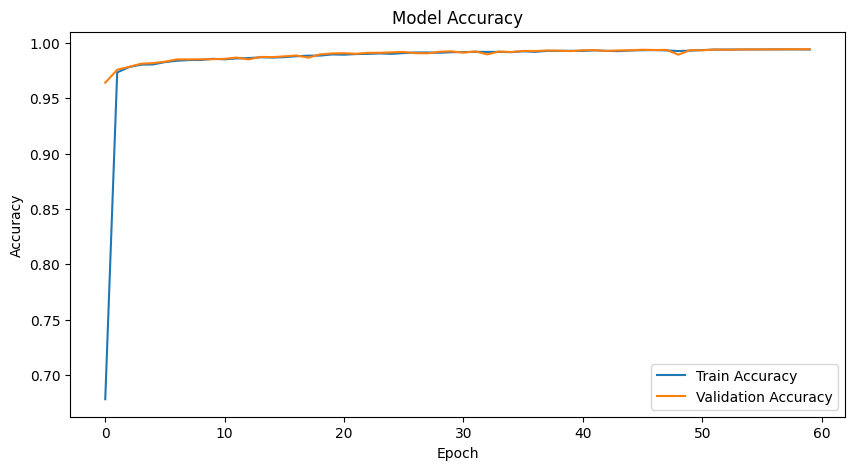

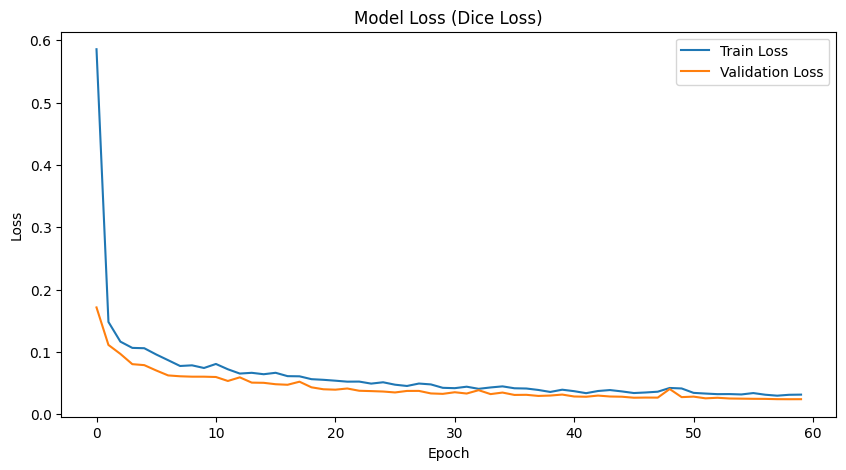

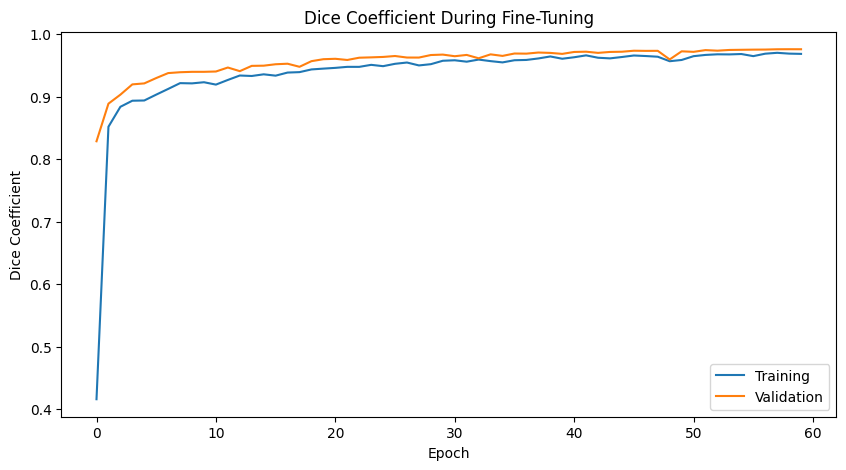

In [ ]:
history = np.load('models_switzerland/TESTMODEL_history.npy', allow_pickle='TRUE').item()

# Plot accuracy and loss for Attention U-Net

## Accuracy
plt.figure(figsize=(10, 5))
plt.plot(history['accuracy'], label='Train Accuracy')
plt.plot(history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='lower right')
plt.show()

## Loss
plt.figure(figsize=(10, 5))
plt.plot(history['loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Model Loss (Dice Loss)')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.show()

# Dice Coeff
plt.figure(figsize=(10, 5))
plt.plot(history['dice_coeff'])
plt.plot(history['val_dice_coeff'])
plt.ylabel('Dice Coefficient')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='lower right')
plt.title('Dice Coefficient During Fine-Tuning')
plt.show()

### TEST 3: Original loss function

In [ ]:
EXPERIMENT = {
    'batch_size': 4,
    'lr': 0.0001,
    'drop_rate': 0.5,
    'patience': 10,
    'epochs': 60,
    'reduce_lr_factor': 0.5
}

In [ ]:
# 1. Create model with experiment settings
loss_model = UNetAM_Transfer(
    trained_weights_path=MODEL_PATH_4BAND,
    input_size=(512, 512, 6),
    drop_rate=EXPERIMENT['drop_rate'],
    lr=EXPERIMENT['lr'],
    loss_fn='binary_crossentropy',
    metrics_list=['mse', 'accuracy']
)


# Training Dataset Pipeline (WITH augmentation)
train_dataset = train_df_switz.shuffle(buffer_size=100) \
                              .map(preprocess_and_augment, num_parallel_calls=tf.data.AUTOTUNE) \
                              .batch(BATCH_SIZE) \
                              .prefetch(tf.data.AUTOTUNE)


val_dataset = val_df_swit.map(preprocess_only, num_parallel_calls=tf.data.AUTOTUNE) \
                         .batch(BATCH_SIZE) \
                         .prefetch(tf.data.AUTOTUNE)

# 4. Setup callbacks
checkpoint = ModelCheckpoint(
    'models_switzerland/ORIGINALLOSSMODEL.keras',  # ← NEW NAME
    monitor='val_accuracy',
    mode='max',
    save_best_only=True,
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=EXPERIMENT['patience'],
    mode='max',
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_accuracy',
    factor=EXPERIMENT.get('reduce_lr_factor', 0.5),
    patience=5,
    mode='max',
    verbose=1,
    min_lr=1e-7
)

callbacks_list = [checkpoint, early_stop, reduce_lr]

# 5. Train
print(f"\nTraining with: batch_size={EXPERIMENT['batch_size']}, lr={EXPERIMENT['lr']}")

history = loss_model.fit(
    train_dataset,
    epochs=EXPERIMENT['epochs'],
    validation_data=val_dataset,
    callbacks=callbacks_list,
    verbose=1
)

# 6. Save experiment results
np.save('models_switzerland/ORIGINALLOSSMODEL_history.npy', loss_model.history.history)


LOADING PRE-TRAINED WEIGHTS
Source: models_paper/unet-attention-4d.keras
✓ Pre-trained model loaded successfully
  Pre-trained layers: 78
  New model layers: 88

Transferring weights (skipping first 6 layers)...

✓ Weight transfer verification:
  Layer 6 has weights: YES
  Sample weight value: -0.109378

✓ Transfer complete:
  Transferred: 9 layers
  Skipped: 21 layers
  First 6 layers: Random init (6-channel input)

  Weight statistics:
    Total params: 2,007,541
    First block (random): 3,200 (0.2%)
    Transferred (Amazon): 2,004,341 (99.8%)

Total parameters: 2,007,541
Trainable parameters: 2,007,541 (100.0%)
Frozen parameters: 0 (0.0%)

Training with: batch_size=4, lr=0.0001
Epoch 1/60
201/201 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step - accuracy: 0.3345 - loss: 2.2173 - mse: 0.4275
Epoch 1: val_accuracy improved from -inf to 0.85427, saving model to models_switzerland/ORIGINALLOSSMODEL.keras
201/201 ━━━━━━━━━━━━━━━━━━━━ 60s 205ms/step - accuracy: 0.3358 - loss: 2.2114 - mse: 0.4268 - 

##### TEST 3: Results

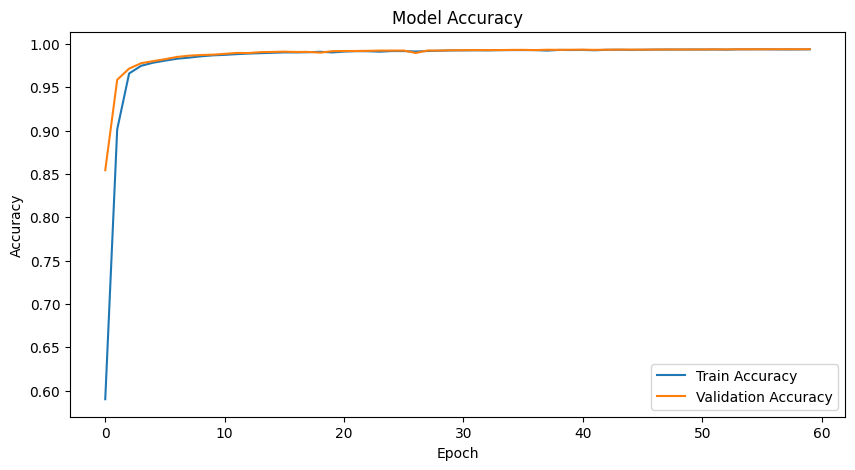

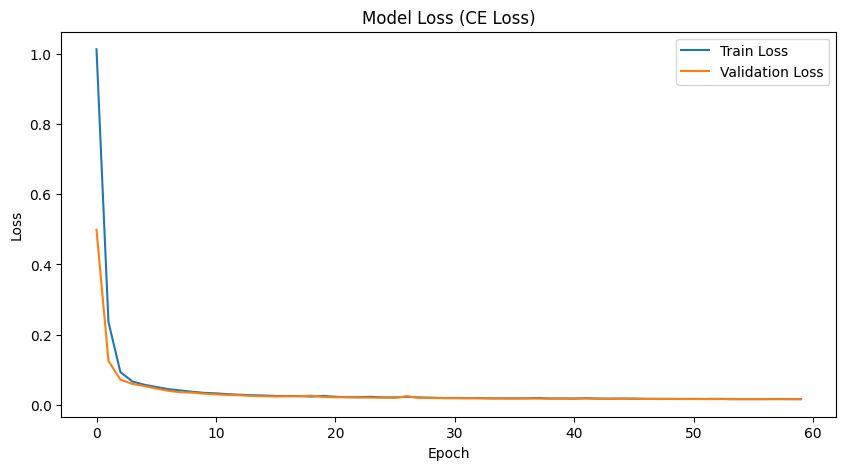

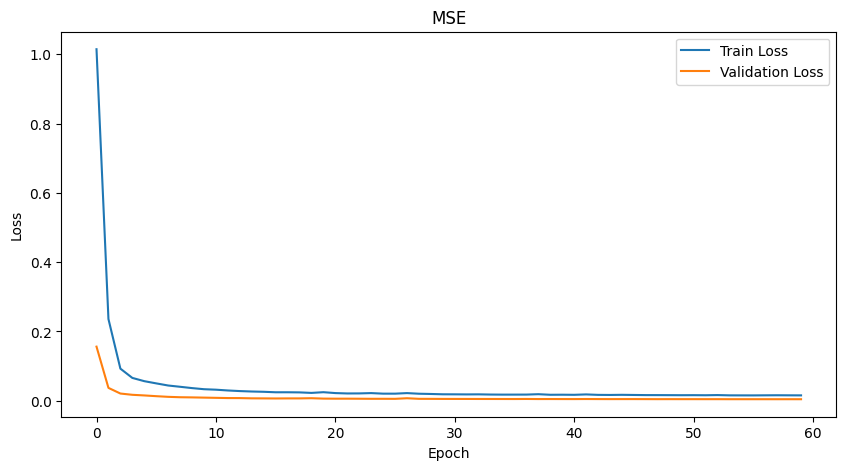

In [ ]:
history = np.load('models_switzerland/ORIGINALLOSSMODEL_history.npy', allow_pickle='TRUE').item()

## Accuracy
plt.figure(figsize=(10, 5))
plt.plot(history['accuracy'], label='Train Accuracy')
plt.plot(history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='lower right')
plt.show()

## Loss
plt.figure(figsize=(10, 5))
plt.plot(history['loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Model Loss (CE Loss)')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.show()


## Loss
plt.figure(figsize=(10, 5))
plt.plot(history['loss'], label='Train Loss')
plt.plot(history['val_mse'], label='Validation Loss')
plt.title('MSE')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.show()

### TEST 4: Change LR w.r.t. Baseline

In [13]:
EXPERIMENT = {
    'batch_size': 4,
    'lr': 0.0001,           # ← CHANGED
    'drop_rate': 0.5,
    'patience': 10,
    'epochs': 60,
    'reduce_lr_factor': 0.5
}

In [14]:
# 1. Create model with experiment settings
test_model = UNetAM_Transfer(
    trained_weights_path=MODEL_PATH_4BAND,
    input_size=(512, 512, 6),
    drop_rate=EXPERIMENT['drop_rate'],
    lr=EXPERIMENT['lr'],
    filter_base=16,
    loss_fn=dice_loss,
    metrics_list=[dice_coeff, 'accuracy']
)


# Training Dataset Pipeline (WITH augmentation)
train_dataset = train_df_switz.shuffle(buffer_size=100) \
                              .map(preprocess_and_augment, num_parallel_calls=tf.data.AUTOTUNE) \
                              .batch(BATCH_SIZE) \
                              .prefetch(tf.data.AUTOTUNE)


val_dataset = val_df_swit.map(preprocess_only, num_parallel_calls=tf.data.AUTOTUNE) \
                         .batch(BATCH_SIZE) \
                         .prefetch(tf.data.AUTOTUNE)

# 4. Setup callbacks
checkpoint = ModelCheckpoint(
    'models_switzerland/TEST_LR.keras',  # ← NEW NAME
    monitor='val_dice_coeff',
    mode='max',
    save_best_only=True,
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_dice_coeff',
    patience=EXPERIMENT['patience'],
    mode='max',
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_dice_coeff',
    factor=EXPERIMENT.get('reduce_lr_factor', 0.5),  # Use custom if specified
    patience=5,
    mode='max',
    verbose=1,
    min_lr=1e-7
)

callbacks_list = [checkpoint, early_stop, reduce_lr]

# 5. Train
print(f"\nTraining with: batch_size={EXPERIMENT['batch_size']}, lr={EXPERIMENT['lr']}")

history = test_model.fit(
    train_dataset,
    epochs=EXPERIMENT['epochs'],
    validation_data=val_dataset,
    callbacks=callbacks_list,
    verbose=1
)

# 6. Save experiment results
np.save('models_switzerland/TEST_LR.npy', test_model.history.history)


LOADING PRE-TRAINED WEIGHTS
Source: models_paper/unet-attention-4d.keras
Pre-trained model loaded successfully
  Pre-trained layers: 78
  New model layers: 88

Transferring weights (skipping first 6 layers)...

 V Weight transfer verification:
  Sample weight value: -0.109378

V Transfer complete:
  Transferred: 9 layers
  Skipped: 21 layers
  First 6 layers: Random init (6-channel input)

  Weight statistics:
    Total params: 2,007,541
    First block (random): 3,200 (0.2%)
    Transferred (Amazon): 2,004,341 (99.8%)

Total parameters: 2,007,541
Trainable parameters: 2,007,541 (100.0%)
Frozen parameters: 0 (0.0%)

Training with: batch_size=4, lr=0.0001
Epoch 1/60
201/201 ━━━━━━━━━━━━━━━━━━━━ 0s 250ms/step - accuracy: 0.5494 - dice_coeff: 0.2982 - loss: 0.7018
Epoch 1: val_dice_coeff improved from -inf to 0.80533, saving model to models_switzerland/TEST_LR.keras
201/201 ━━━━━━━━━━━━━━━━━━━━ 102s 290ms/step - accuracy: 0.5505 - dice_coeff: 0.2994 - loss: 0.7006 - val_accuracy: 0.9564 

#### TEST 4: Results

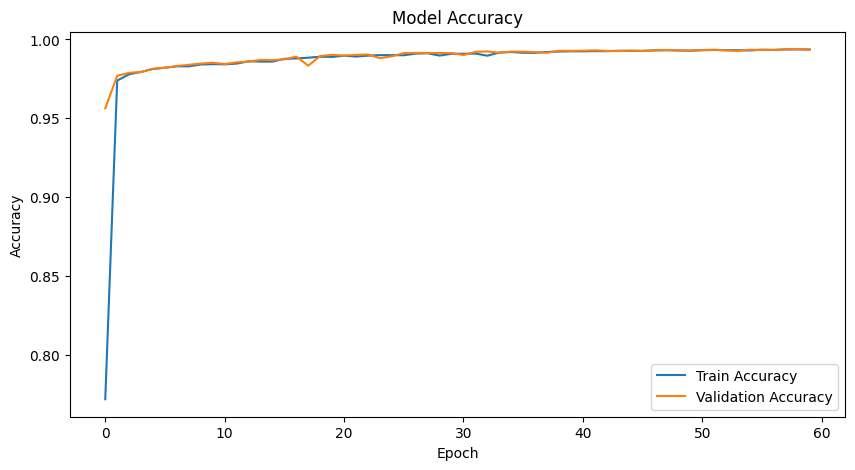

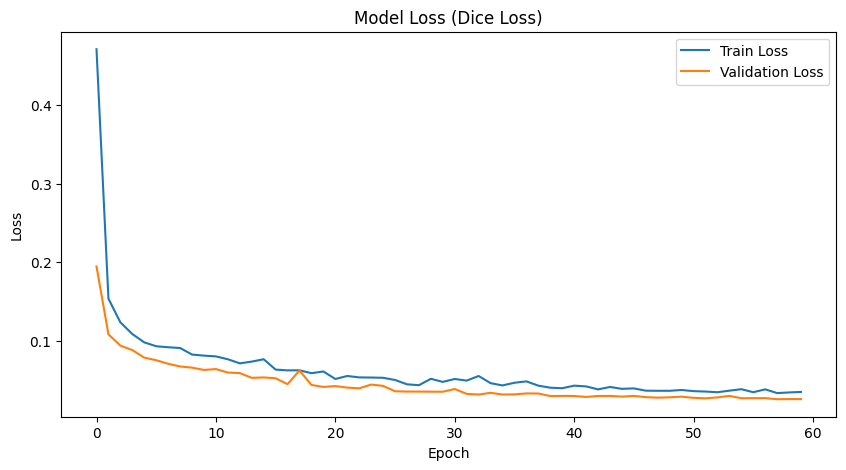

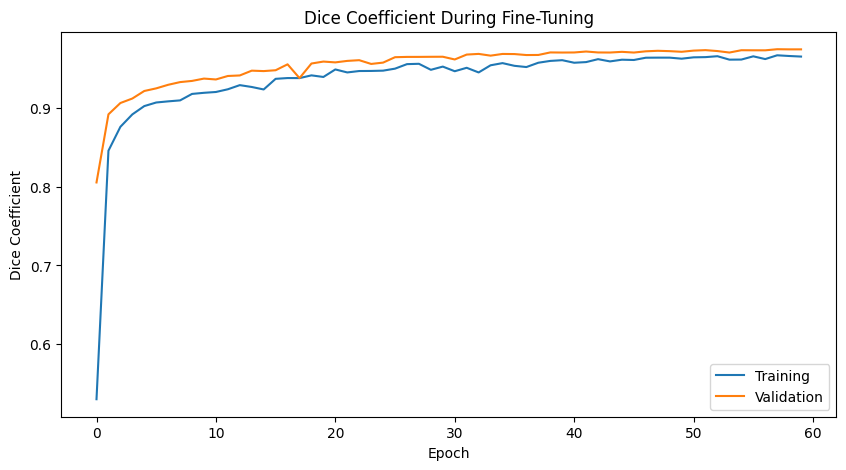

In [15]:
history = np.load('models_switzerland/TEST_LR.npy', allow_pickle='TRUE').item()

## Accuracy
plt.figure(figsize=(10, 5))
plt.plot(history['accuracy'], label='Train Accuracy')
plt.plot(history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='lower right')
plt.show()

## Loss
plt.figure(figsize=(10, 5))
plt.plot(history['loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Model Loss (Dice Loss)')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.show()


# Dice Coeff
plt.figure(figsize=(10, 5))
plt.plot(history['dice_coeff'])
plt.plot(history['val_dice_coeff'])
plt.ylabel('Dice Coefficient')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='lower right')
plt.title('Dice Coefficient During Fine-Tuning')
plt.show()

### TEST 5: Change LR regulation w.r.t. baseline

In [16]:
EXPERIMENT = {
    'batch_size': 4,
    'lr': 0.00005,
    'drop_rate': 0.5,
    'patience': 10,
    'epochs': 60,
    'reduce_lr_factor': 0.3  # ← Change aggressive LR reduction
}

In [17]:
# 1. Create model with experiment settings
test_model = UNetAM_Transfer(
    trained_weights_path=MODEL_PATH_4BAND,
    input_size=(512, 512, 6),
    drop_rate=EXPERIMENT['drop_rate'],
    lr=EXPERIMENT['lr'],
    filter_base=16,
    loss_fn=dice_loss,
    metrics_list=[dice_coeff, 'accuracy']
)


# Training Dataset Pipeline (WITH augmentation)
train_dataset = train_df_switz.shuffle(buffer_size=100) \
                              .map(preprocess_and_augment, num_parallel_calls=tf.data.AUTOTUNE) \
                              .batch(BATCH_SIZE) \
                              .prefetch(tf.data.AUTOTUNE)


val_dataset = val_df_swit.map(preprocess_only, num_parallel_calls=tf.data.AUTOTUNE) \
                         .batch(BATCH_SIZE) \
                         .prefetch(tf.data.AUTOTUNE)

# 4. Setup callbacks
checkpoint = ModelCheckpoint(
    'models_switzerland/LR_SCHEDULER.keras',  # ← NEW NAME
    monitor='val_dice_coeff',
    mode='max',
    save_best_only=True,
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_dice_coeff',
    patience=EXPERIMENT['patience'],
    mode='max',
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_dice_coeff',
    factor=EXPERIMENT.get('reduce_lr_factor', 0.5),  # Use custom if specified
    patience=5,
    mode='max',
    verbose=1,
    min_lr=1e-7
)

callbacks_list = [checkpoint, early_stop, reduce_lr]

# 5. Train
print(f"\nTraining with: batch_size={EXPERIMENT['batch_size']}, lr={EXPERIMENT['lr']}")

history = test_model.fit(
    train_dataset,
    epochs=EXPERIMENT['epochs'],
    validation_data=val_dataset,
    callbacks=callbacks_list,
    verbose=1
)

# 6. Save experiment results
np.save('models_switzerland/LR_SCHEDULER_history.npy', test_model.history.history)


LOADING PRE-TRAINED WEIGHTS
Source: models_paper/unet-attention-4d.keras
Pre-trained model loaded successfully
  Pre-trained layers: 78
  New model layers: 88

Transferring weights (skipping first 6 layers)...

 V Weight transfer verification:
  Sample weight value: -0.109378

V Transfer complete:
  Transferred: 9 layers
  Skipped: 21 layers
  First 6 layers: Random init (6-channel input)

  Weight statistics:
    Total params: 2,007,541
    First block (random): 3,200 (0.2%)
    Transferred (Amazon): 2,004,341 (99.8%)

Total parameters: 2,007,541
Trainable parameters: 2,007,541 (100.0%)
Frozen parameters: 0 (0.0%)

Training with: batch_size=4, lr=5e-05
Epoch 1/60
201/201 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step - accuracy: 0.4481 - dice_coeff: 0.2002 - loss: 0.7998
Epoch 1: val_dice_coeff improved from -inf to 0.36542, saving model to models_switzerland/LR_SCHEDULER.keras
201/201 ━━━━━━━━━━━━━━━━━━━━ 66s 221ms/step - accuracy: 0.4489 - dice_coeff: 0.2007 - loss: 0.7993 - val_accuracy: 0.90

#### TEST 5: Results

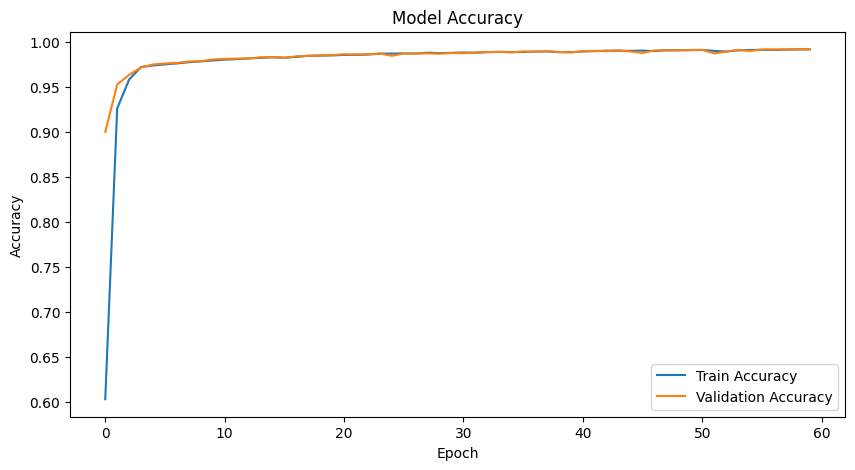

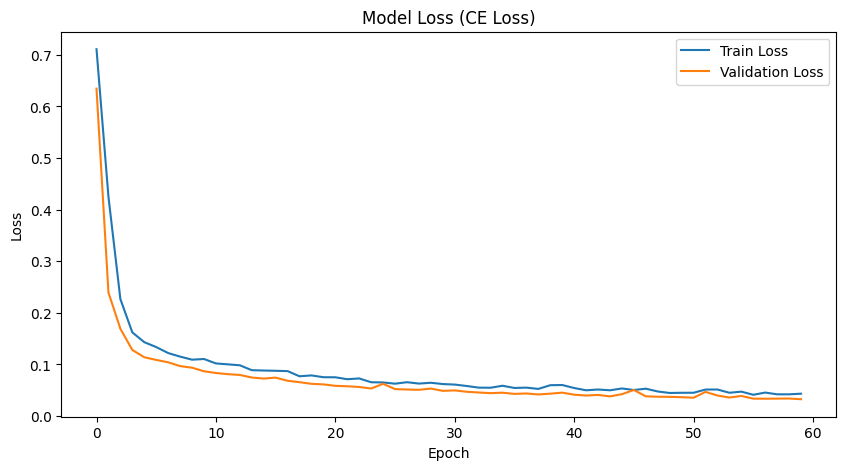

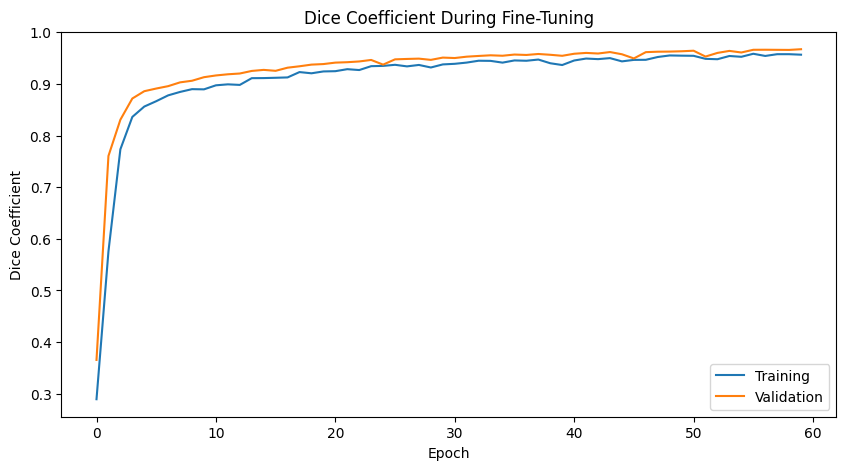

In [19]:
history = np.load('models_switzerland/LR_SCHEDULER_history.npy', allow_pickle='TRUE').item()

## Accuracy
plt.figure(figsize=(10, 5))
plt.plot(history['accuracy'], label='Train Accuracy')
plt.plot(history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='lower right')
plt.show()

## Loss
plt.figure(figsize=(10, 5))
plt.plot(history['loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Model Loss (CE Loss)')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.show()


# Dice Coeff
plt.figure(figsize=(10, 5))
plt.plot(history['dice_coeff'])
plt.plot(history['val_dice_coeff'])
plt.ylabel('Dice Coefficient')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='lower right')
plt.title('Dice Coefficient During Fine-Tuning')
plt.show()

In [21]:
import shutil
from google.colab import files

# Create ZIP file
shutil.make_archive("models_switzerland_backup", "zip", "models_switzerland")

# Download ZIP
files.download("models_switzerland_backup.zip")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### TEST 6

In [26]:
EXPERIMENT = {
    'batch_size': 4,
    'lr': 0.0001,
    'drop_rate': 0.5,
    'patience': 10,
    'epochs': 60,
    'reduce_lr_factor': 0.3
}

In [27]:
# 1. Create model with experiment settings
test_model = UNetAM_Transfer(
    trained_weights_path=MODEL_PATH_4BAND,
    input_size=(512, 512, 6),
    drop_rate=EXPERIMENT['drop_rate'],
    lr=EXPERIMENT['lr'],
    filter_base=16,
    loss_fn=dice_loss,
    metrics_list=[dice_coeff, 'accuracy']
)


# Training Dataset Pipeline (WITH augmentation)
train_dataset = train_df_switz.shuffle(buffer_size=100) \
                              .map(preprocess_and_augment, num_parallel_calls=tf.data.AUTOTUNE) \
                              .batch(BATCH_SIZE) \
                              .prefetch(tf.data.AUTOTUNE)


val_dataset = val_df_swit.map(preprocess_only, num_parallel_calls=tf.data.AUTOTUNE) \
                         .batch(BATCH_SIZE) \
                         .prefetch(tf.data.AUTOTUNE)

# 4. Setup callbacks
checkpoint = ModelCheckpoint(
    'models_switzerland/LR_AND_SCHEDULER.keras',  # ← NEW NAME
    monitor='val_dice_coeff',
    mode='max',
    save_best_only=True,
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_dice_coeff',
    patience=EXPERIMENT['patience'],
    mode='max',
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_dice_coeff',
    factor=EXPERIMENT.get('reduce_lr_factor', 0.5),  # Use custom if specified
    patience=5,
    mode='max',
    verbose=1,
    min_lr=1e-7
)

callbacks_list = [checkpoint, early_stop, reduce_lr]

# 5. Train
print(f"\nTraining with: batch_size={EXPERIMENT['batch_size']}, lr={EXPERIMENT['lr']}")

history = test_model.fit(
    train_dataset,
    epochs=EXPERIMENT['epochs'],
    validation_data=val_dataset,
    callbacks=callbacks_list,
    verbose=1
)

# 6. Save experiment results
np.save('models_switzerland/LR_AND_SCHEDULER.npy', test_model.history.history)


LOADING PRE-TRAINED WEIGHTS
Source: models_paper/unet-attention-4d.keras
Pre-trained model loaded successfully
  Pre-trained layers: 78
  New model layers: 88

Transferring weights (skipping first 6 layers)...

 V Weight transfer verification:
  Sample weight value: -0.109378

V Transfer complete:
  Transferred: 9 layers
  Skipped: 21 layers
  First 6 layers: Random init (6-channel input)

  Weight statistics:
    Total params: 2,007,541
    First block (random): 3,200 (0.2%)
    Transferred (Amazon): 2,004,341 (99.8%)

Total parameters: 2,007,541
Trainable parameters: 2,007,541 (100.0%)
Frozen parameters: 0 (0.0%)

Training with: batch_size=4, lr=0.0001
Epoch 1/60
201/201 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step - accuracy: 0.5237 - dice_coeff: 0.2136 - loss: 0.7864
Epoch 1: val_dice_coeff improved from -inf to 0.84701, saving model to models_switzerland/LR_AND_SCHEDULER.keras
201/201 ━━━━━━━━━━━━━━━━━━━━ 67s 217ms/step - accuracy: 0.5243 - dice_coeff: 0.2147 - loss: 0.7853 - val_accuracy:

#### TEST 6: Results

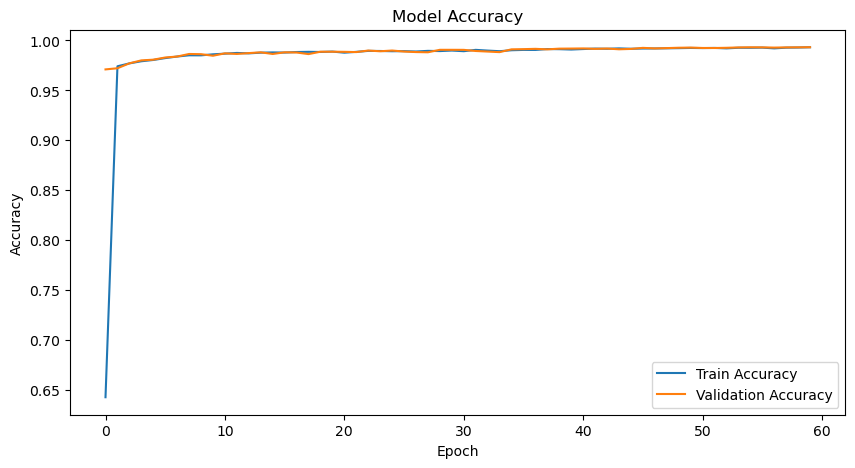

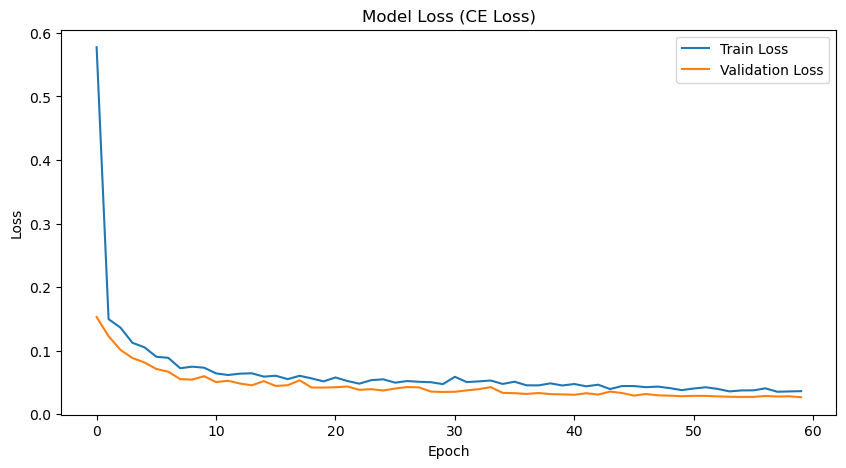

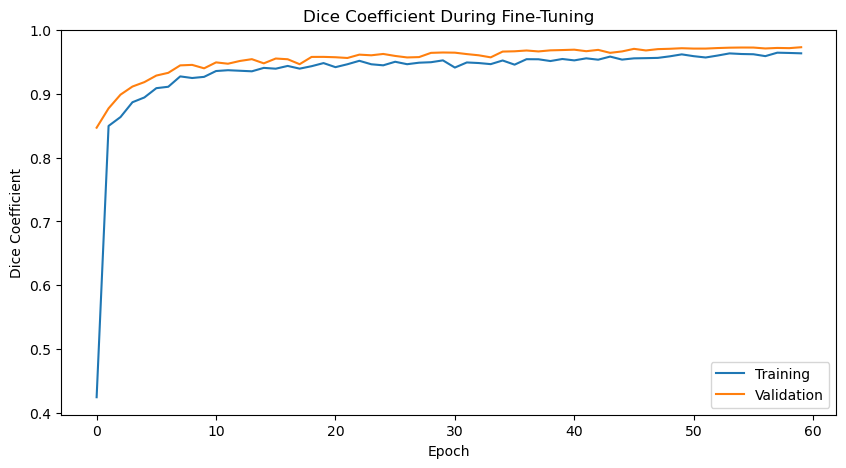

In [3]:
history = np.load('models_switzerland/LR_AND_SCHEDULER.npy', allow_pickle='TRUE').item()

## Accuracy
plt.figure(figsize=(10, 5))
plt.plot(history['accuracy'], label='Train Accuracy')
plt.plot(history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='lower right')
plt.show()

## Loss
plt.figure(figsize=(10, 5))
plt.plot(history['loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Model Loss (CE Loss)')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.show()


# Dice Coeff
plt.figure(figsize=(10, 5))
plt.plot(history['dice_coeff'])
plt.plot(history['val_dice_coeff'])
plt.ylabel('Dice Coefficient')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='lower right')
plt.title('Dice Coefficient During Fine-Tuning')
plt.show()

## Comparison


In [4]:
# --------------------------------------------------
# 1. Define your 3 model histories
# --------------------------------------------------
models = [
    {
        "name": "Model_1_Dice",
        "path": "models_switzerland/glacier_attention_unet_6band_history.npy"
    },
    {
        "name": "Model_2_Dice_Aggresive",
        "path": "models_switzerland/TESTMODEL_history.npy"
    },
    {
        "name": "Model_3_BCE",
        "path": "models_switzerland/ORIGINALLOSSMODEL_history.npy"
    },

    {
        "name": "Model_4_LR",
        "path": "models_switzerland/TEST_LR.npy"
    },

    {
        "name": "Model_5_LR_Scheduler",
        "path": "models_switzerland/LR_SCHEDULER_history.npy"
    },

    {
        "name": "Model_6_LR_AND_SCHEDULER",
        "path": "models_switzerland/LR_AND_SCHEDULER.npy"
    },
]

# --------------------------------------------------
# 2. Helper: load history dict from npy
# --------------------------------------------------
def load_history(path):
    hist = np.load(path, allow_pickle=True).item()
    return hist

# --------------------------------------------------
# 3. Build comparison table
# --------------------------------------------------
summary_rows = []

for m in models:
    h = load_history(m["path"])

    # Safely get metrics if they exist
    def get_last(key):
        return h[key][-1] if key in h else None

    def get_best(key, mode="max"):
        if key not in h:
            return None
        if mode == "max":
            return float(np.max(h[key]))
        else:
            return float(np.min(h[key]))

    row = {
        "model": m["name"],

        # Final values (last epoch)
        "final_train_loss":   get_last("loss"),
        "final_val_loss":     get_last("val_loss"),
        "final_train_acc":    get_last("accuracy"),
        "final_val_acc":      get_last("val_accuracy"),
        "final_train_dice":   get_last("dice_coeff"),
        "final_val_dice":     get_last("val_dice_coeff"),

        # Best values over all epochs
        "best_val_loss":      get_best("val_loss", mode="min"),
        "best_val_acc":       get_best("val_accuracy", mode="max"),
        "best_val_dice":      get_best("val_dice_coeff", mode="max"),
    }

    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
print("\n=== Model Comparison Table ===")
display(summary_df)



=== Model Comparison Table ===


,model,final_train_loss,final_val_loss,final_train_acc,final_val_acc,final_train_dice,final_val_dice,best_val_loss,best_val_acc,best_val_dice
0,Model_1_Dice,0.011266,0.045555,0.994259,0.988373,0.988734,0.954445,0.045555,0.988373,0.954445
1,Model_2_Dice_Aggresive,0.031420,0.024089,0.994162,0.994409,0.968497,0.975911,0.024042,0.994423,0.975958
2,Model_3_BCE,0.015657,0.015320,0.993637,0.993773,NaN,NaN,0.015320,0.993773,NaN
3,Model_4_LR,0.034935,0.025827,0.993566,0.993708,0.965035,0.974173,0.025652,0.993793,0.974348
4,Model_5_LR_Scheduler,0.043393,0.032668,0.991949,0.992150,0.956742,0.967332,0.032668,0.992150,0.967332
5,Model_6_LR_AND_SCHEDULER,0.036286,0.026735,0.993220,0.993260,0.963690,0.973265,0.026735,0.993260,0.973265


### On test set

In [15]:
test_models = [
    {
        "name": "Model_1_Dice",
        "path": "models_switzerland/glacier_attention_unet_6band.keras"
    },
    {
        "name": "Model_2_Dice_Aggresive",
        "path": "models_switzerland/TESTMODEL.keras"
    },
    {
        "name": "Model_3_BCE",
        "path": "models_switzerland/ORIGINALLOSSMODEL.keras"
    },

    {
        "name": "Model_4_LR",
        "path": "models_switzerland/TEST_LR.keras"
    },

    {
        "name": "Model_5_LR_Scheduler",
        "path": "models_switzerland/LR_SCHEDULER.keras"
    },

    {
        "name": "Model_6_LR_AND_SCHEDULER",
        "path": "models_switzerland/LR_AND_SCHEDULER.keras"
    },
]


test_df_swit = tf.data.Dataset.from_tensor_slices((test_images2, test_masks2))
test_dataset = test_df_swit.map(preprocess_only, num_parallel_calls=tf.data.AUTOTUNE) \
                           .batch(BATCH_SIZE)  # same BATCH_SIZE as in training


In [18]:
test_rows = []

for m in test_models:
    print(f"\nEvaluating on test set: {m['name']}")

    model = load_model(
        m["path"],
        custom_objects={"dice_coeff": dice_coeff, "dice_loss": dice_loss},
        compile=True
    )

    # This returns: [loss, dice_coeff, accuracy] if you compiled with metrics_list=[dice_coeff, 'accuracy']
    results = model.evaluate(test_dataset, verbose=1)
    loss, dice, acc = results[0], results[1], results[2]

    row = {
        "model": m["name"],
        "test_loss": loss,
        "test_dice": dice,
        "test_f1": dice,        # Dice == F1 for binary segmentation
        "test_accuracy": acc
    }
    test_rows.append(row)

test_df = pd.DataFrame(test_rows)
print("\n=== Test Set Performance ===")
display(test_df)



Evaluating on test set: Model_1_Dice
26/26 ━━━━━━━━━━━━━━━━━━━━ 18s 595ms/step - accuracy: 0.9915 - dice_coeff: 0.9446 - loss: 0.0552

Evaluating on test set: Model_2_Dice_Aggresive
26/26 ━━━━━━━━━━━━━━━━━━━━ 18s 638ms/step - accuracy: 0.9954 - dice_coeff: 0.9694 - loss: 0.0304

Evaluating on test set: Model_3_BCE
26/26 ━━━━━━━━━━━━━━━━━━━━ 18s 660ms/step - accuracy: 0.9949 - loss: 0.0129 - mse: 0.0038

Evaluating on test set: Model_4_LR
26/26 ━━━━━━━━━━━━━━━━━━━━ 22s 775ms/step - accuracy: 0.9950 - dice_coeff: 0.9675 - loss: 0.0322

Evaluating on test set: Model_5_LR_Scheduler
26/26 ━━━━━━━━━━━━━━━━━━━━ 20s 718ms/step - accuracy: 0.9939 - dice_coeff: 0.9597 - loss: 0.0402

Evaluating on test set: Model_6_LR_AND_SCHEDULER
26/26 ━━━━━━━━━━━━━━━━━━━━ 20s 729ms/step - accuracy: 0.9948 - dice_coeff: 0.9673 - loss: 0.0325

=== Test Set Performance ===


,model,test_loss,test_dice,test_f1,test_accuracy
0,Model_1_Dice,0.055168,0.991503,0.991503,0.944640
1,Model_2_Dice_Aggresive,0.030406,0.969392,0.969392,0.995390
2,Model_3_BCE,0.012875,0.003776,0.003776,0.994875
3,Model_4_LR,0.032183,0.967547,0.967547,0.995004
4,Model_5_LR_Scheduler,0.040215,0.959673,0.959673,0.993919
5,Model_6_LR_AND_SCHEDULER,0.032523,0.967319,0.967319,0.994809


# Model choice

Model 2 fwith the following parameters:

In [ ]:
PARAMETERS = {
    'batch_size': 2,  
    'epochs': 60,
    'loss': Dice Loss,

    'learning_rate': 0.0001,  
    'reduce_learning_rate_factor': 0.3,
    'patience_learning_rate': 5,
       
    'drop_rate': 0.5,
    'patience_early_stopping': 10,
}

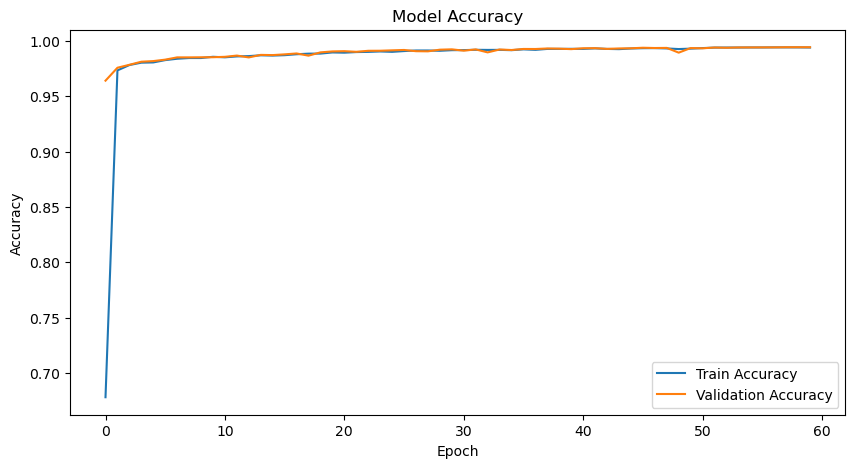

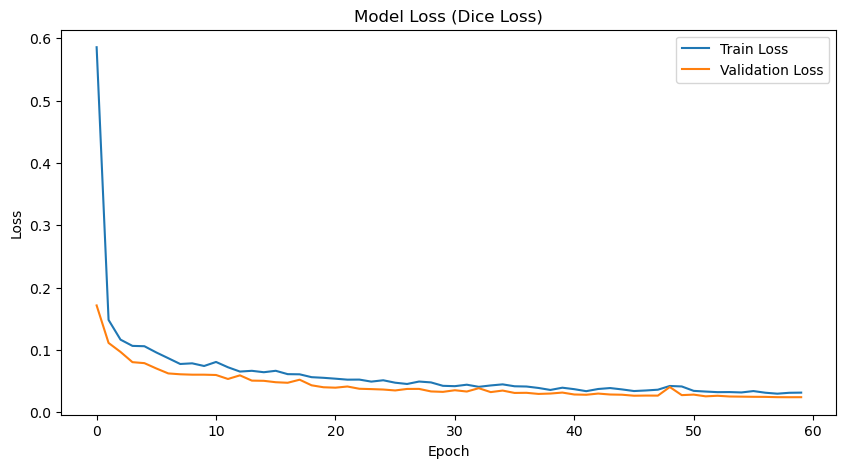

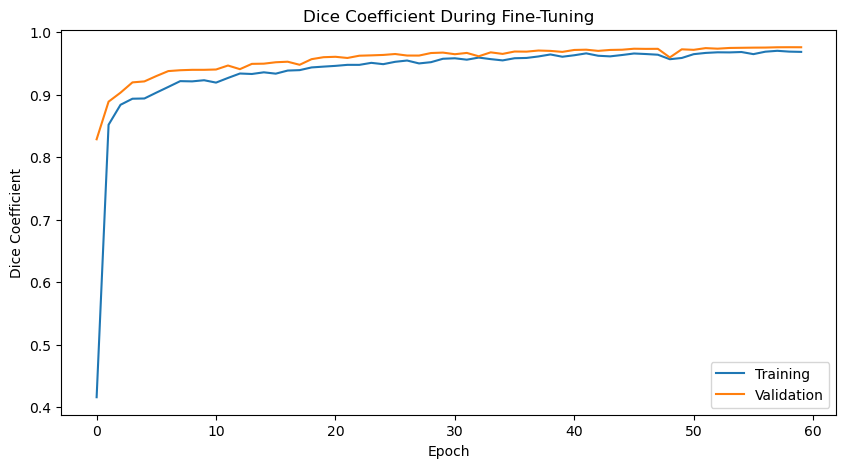

In [19]:
history = np.load('models_switzerland/TESTMODEL_history.npy', allow_pickle='TRUE').item()

# Plot accuracy and loss for Attention U-Net

## Accuracy
plt.figure(figsize=(10, 5))
plt.plot(history['accuracy'], label='Train Accuracy')
plt.plot(history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='lower right')
plt.show()

## Loss
plt.figure(figsize=(10, 5))
plt.plot(history['loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Model Loss (Dice Loss)')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.show()

# Dice Coeff
plt.figure(figsize=(10, 5))
plt.plot(history['dice_coeff'])
plt.plot(history['val_dice_coeff'])
plt.ylabel('Dice Coefficient')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='lower right')
plt.title('Dice Coefficient During Fine-Tuning')
plt.show()

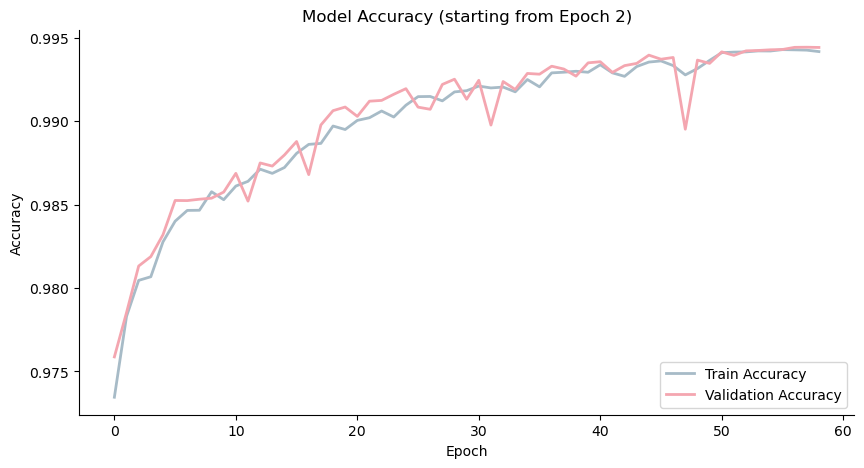

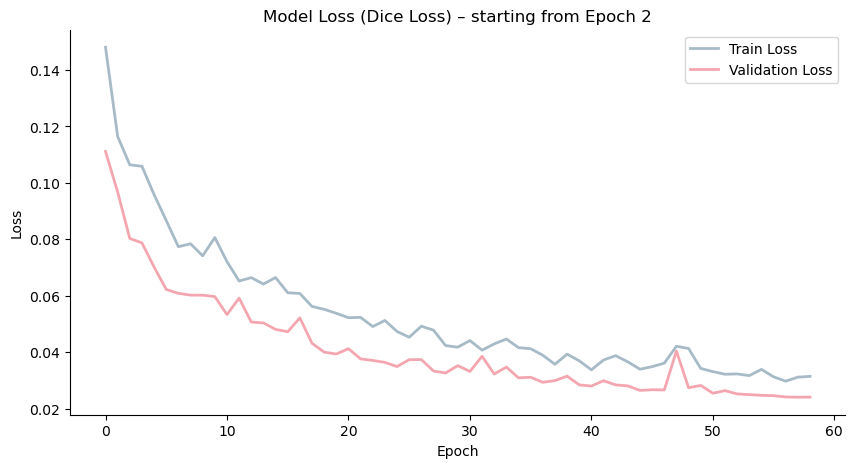

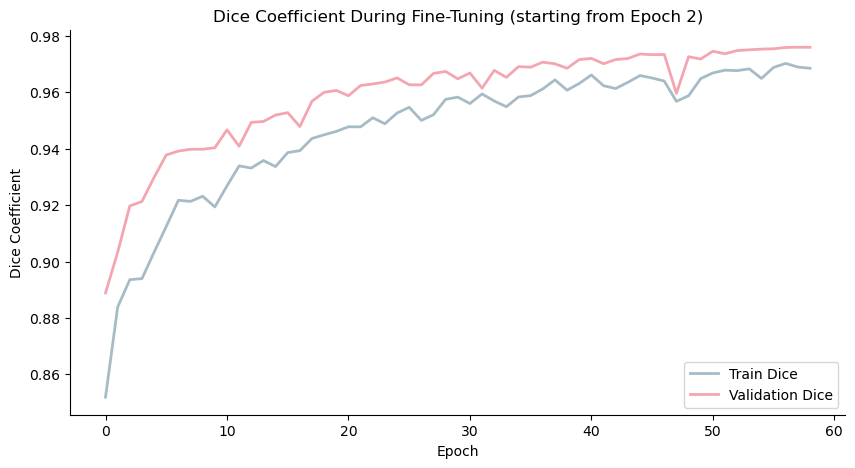

In [22]:
history = np.load('models_switzerland/TESTMODEL_history.npy', allow_pickle=True).item()

# Slice vanaf epoch 2
acc      = history['accuracy'][1:]
val_acc  = history['val_accuracy'][1:]
loss     = history['loss'][1:]
val_loss = history['val_loss'][1:]
dice     = history['dice_coeff'][1:]
val_dice = history['val_dice_coeff'][1:]

# Soft pastel colors
train_color = "#A7BBC7"   # grey-blue pastel
val_color   = "#F4A6B0"   # pastel pink

def clean_style(ax):
    """Remove top/right spines for minimalist academic styling."""
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# ---- Accuracy ----
fig, ax = plt.subplots(figsize=(10,5))
ax.plot(acc, label='Train Accuracy', color=train_color, linewidth=2)
ax.plot(val_acc, label='Validation Accuracy', color=val_color, linewidth=2)
clean_style(ax)
ax.set_title('Model Accuracy (starting from Epoch 2)')
ax.set_ylabel('Accuracy')
ax.set_xlabel('Epoch')
ax.legend(loc='lower right')
plt.show()

# ---- Loss ----
fig, ax = plt.subplots(figsize=(10,5))
ax.plot(loss, label='Train Loss', color=train_color, linewidth=2)
ax.plot(val_loss, label='Validation Loss', color=val_color, linewidth=2)
clean_style(ax)
ax.set_title('Model Loss (Dice Loss) – starting from Epoch 2')
ax.set_ylabel('Loss')
ax.set_xlabel('Epoch')
ax.legend(loc='upper right')
plt.show()

# ---- Dice Coefficient ----
fig, ax = plt.subplots(figsize=(10,5))
ax.plot(dice, label='Train Dice', color=train_color, linewidth=2)
ax.plot(val_dice, label='Validation Dice', color=val_color, linewidth=2)
clean_style(ax)
ax.set_title('Dice Coefficient During Fine-Tuning (starting from Epoch 2)')
ax.set_ylabel('Dice Coefficient')
ax.set_xlabel('Epoch')
ax.legend(loc='lower right')
plt.show()
